Importanto bibliotecas


In [ ]:
! pip install h5py
! pip install numpy
! pip install matplotlib
! pip install ipywidgets

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

Equação de Langevin 


$$
\gamma dx = - V'(x) f(t)dt + g dW
$$

De forma que $dW$ é um processo de Winner, Por simplicidade vamos incorporar $\gamma$ nos outros termos da equação, deixando-a da forma:

$$
dx = - V'(x) f(t)dt + g dW
$$
Vamos discretizar o tempo para um determinado intervalo $\delta t$ e escrever a equação na forma:

$$
x(\delta t\cdot (n+1)) - x(\delta t \cdot n) = - V'(x)f(n\cdot \delta t)\delta t + g dW_{\delta t}
$$

Pelas propriedades de um processo de Wiener, temos que:

$$
dW_{\delta t} \sim  Norm(0, \delta t)
$$

Onde $Norm(0, \sigma^2)$ é uma distribuição normal de média $0$ e variancia $\sigma ^2$. Além disso, cada passo $dW$ é independente dos passos anteriores.

O que temos que resolver é a equação discreta:
$$
x_{n+1} - x_n =  - V'(x)f_n \delta t + gdW_{\delta t}
$$
dado 
$$
x_0
$$


In [2]:
class langevin:
    def __init__(self, dt: float, tau_resposta: float, g: float,N_pontos: int, vderivada, funcao_resposta):
        self.dt = dt
        self.tau_resposta = tau_resposta
        self.g = g
        self.N_pontos = N_pontos
        self.funcao_resposta = funcao_resposta
        self.vderivada = vderivada
    def V_derivada(self, x: np.ndarray) -> np.ndarray:
        return self.vderivada(x)
    def Funcao_resposta(self, n:int) -> float:
        # n aqui não é o número de pontos e sim em que passo estamos
        return self.funcao_resposta(n)
    def winner_process(self, dt: float, N_pontos: int) -> np.ndarray:
        return np.random.normal(0, np.sqrt(dt), N_pontos)  
    def resolver_ate_n(self, N:int, x0:float, quando_salvar_passo: int, bins: int = 100,range_hist: tuple = None, nome_arquivo: str = "dados.h5"):
        N_p = self.N_pontos
        x_atual = np.full(N_p, x0)
        dt = self.dt
        g = self.g
        N_salvos = (N - 1) // quando_salvar_passo + 1
        with h5py.File(nome_arquivo, "w") as f:
            histogramas = f.create_dataset("histogramas", shape=(N_salvos, bins), dtype=np.float64)
            tempos = f.create_dataset("tempo", shape = (N_salvos, ), dtype = np.float64)
            bins_dataset = f.create_dataset("bins",shape=(bins,),dtype=np.float64)
            indice_histograma = 0
            
            for i in range(N):
                f = self.Funcao_resposta(i)
                dw = self.winner_process(dt=dt, N_pontos=N_p)
                dV = self.V_derivada(x_atual)
                x_novo = x_atual - dV*f*dt + dw*g
                
                if i % quando_salvar_passo == 0:
                    hist, edges = np.histogram(
                        x_novo,
                        bins=bins,
                        range=range_hist,
                        density=True
                        )
                    centros = (edges[:-1] + edges[1:]) / 2
                    histogramas[indice_histograma] = hist
                    tempos[indice_histograma] = i
                    bins_dataset[:] = centros
                    indice_histograma += 1
                x_atual = x_novo
    def resolver_ate_n_estatisticas(self, N:int, x0:float):
        N_p = self.N_pontos
        x_atual = np.full(N_p, x0)
        dt = self.dt
        g = self.g
        times = np.arange(N)*dt
        media = np.zeros(N)
        var = np.zeros(N)


        for i in range(N):
            f = self.Funcao_resposta(i)
            dw = self.winner_process(dt=dt, N_pontos=N_p)
            dV = self.V_derivada(x_atual)
            x_novo = x_atual - dV*f*dt + dw*g
            x_atual = x_novo
            media[i] = np.mean(x_atual)
            var[i] = np.var(x_atual)

        return times, media, var

            



Escrevemos uma classe que nós ajuda a simular a equação de movimento. O método resolver_ate_n simula a equação diferencial estocástica até um passo $n$ no tempo. Além disso, a distribuição é salva em disco a cada 'quando_salvar_passo' no formato .h5.
Istó nos dá uma matriz $P_{jn}$ que é similar a distribuição de probabilidade $p(x,t)$.

In [ ]:
def po

In [22]:
def potencial_zero(x):
    return np.zeros_like(x)


def resposta_zero(n):
    return 0.0


# ============================================================
# Criando o Langevin
# ============================================================

sim = langevin(
    dt=0.001,
    tau_resposta=1.0,
    g=1.0,
    N_pontos=100000,
    vderivada=potencial_zero,
    funcao_resposta=resposta_zero
)

In [20]:



# ============================================================
# Simulação
# ============================================================

sim.resolver_ate_n(
    N=1000,
    x0=0.0,
    quando_salvar_passo=2,
    bins=200,
    range_hist=(-5, 5),
    nome_arquivo="movimento_aleatorio.h5"
)

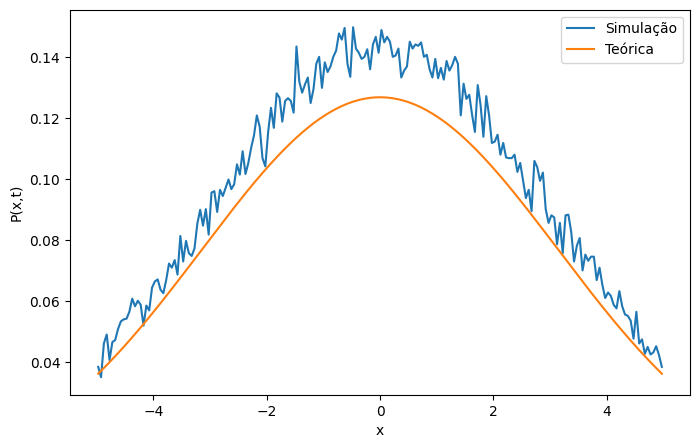

In [27]:
with h5py.File("movimento_aleatorio.h5", "r") as arquivo:

    P = arquivo["histogramas"][:]
    tempos = arquivo["tempo"][:]
    x = arquivo["bins"][:]

P_final = P[-1]
t_final = tempos[-1] * 0.001

plt.figure(figsize=(8, 5))

plt.plot(x, P_final, label="Simulação")


# Solução teórica
P_teorica = (
    1 / np.sqrt(2 * np.pi * sim.g**2 * t_final)
    * np.exp(-x**2 / (2 * sim.g**2 * t_final))
)

plt.plot(x, P_teorica, label="Teórica")

plt.xlabel("x")
plt.ylabel("P(x,t)")
plt.legend()
plt.show()

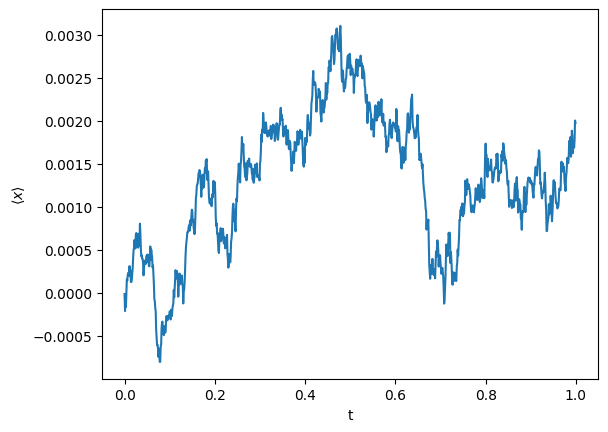

In [17]:
times, media, var = sim.resolver_ate_n_estatisticas(N=1000,x0=0)

plt.plot(times, media)
plt.xlabel("t")
plt.ylabel(r"$\langle x\rangle$")
plt.show()

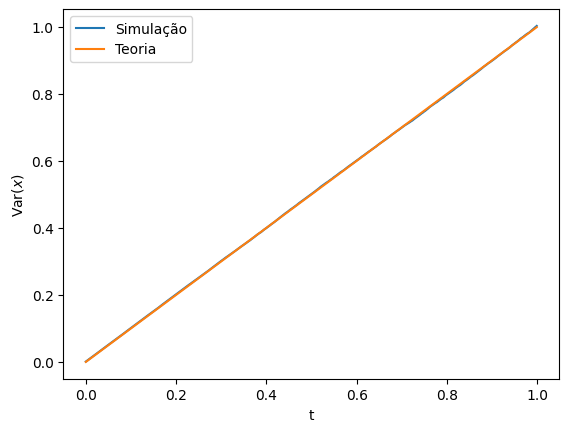

In [18]:
plt.plot(times, var, label="Simulação")
plt.plot(times, sim.g**2 * times, label="Teoria")

plt.xlabel("t")
plt.ylabel(r"$\mathrm{Var}(x)$")
plt.legend()
plt.show()

In [23]:


# Carrega os dados
with h5py.File("movimento_aleatorio.h5", "r") as arquivo:
    P = arquivo["histogramas"][:]
    tempos = arquivo["tempo"][:]
    x = arquivo["bins"][:]

# Slider
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(tempos) - 1,
    step=1,
    description="Tempo:",
    continuous_update=True
)

# Função que desenha o gráfico
def atualizar(indice):
    plt.figure(figsize=(9, 5))

    plt.plot(x, P[indice], linewidth=2)

    plt.xlabel("$x$")
    plt.ylabel("$P(x,t)$")
    plt.title(f"Distribuição em t = {tempos[indice]:.3f}")

    plt.xlim(x[0], x[-1])
    plt.ylim(0, P.max() * 1.1)

    plt.grid(alpha=0.2)
    plt.show()

# Liga o slider à função
widgets.interact(
    atualizar,
    indice=slider
);

interactive(children=(IntSlider(value=0, description='Tempo:', max=499), Output()), _dom_classes=('widget-inte…